# Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Visualize Sample Images

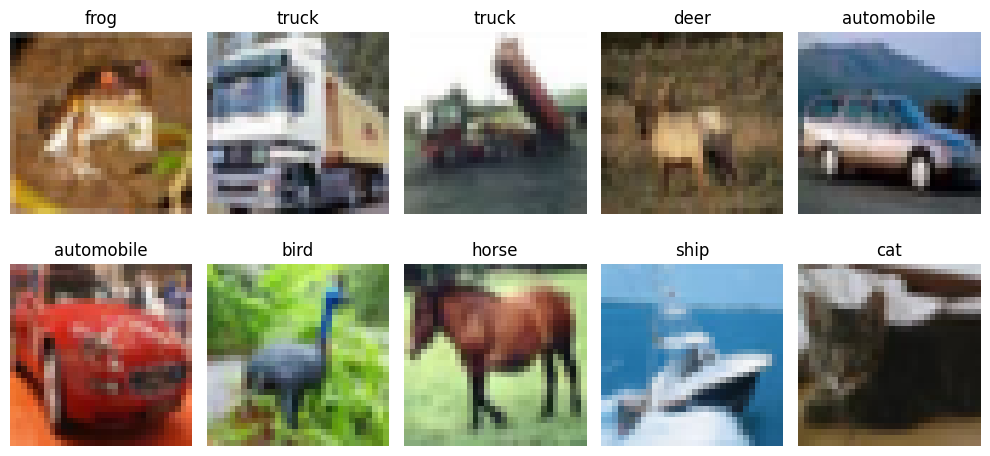

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2692 - loss: 1.9954 - val_accuracy: 0.3208 - val_loss: 1.8648
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3165 - loss: 1.8748 - val_accuracy: 0.3558 - val_loss: 1.7907
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3370 - loss: 1.8175 - val_accuracy: 0.3844 - val_loss: 1.7354
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3566 - loss: 1.7726 - val_accuracy: 0.4006 - val_loss: 1.6975
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3650 - loss: 1.7500 - val_accuracy: 0.3884 - val_loss: 1.7356
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3707 - loss: 1.7326 - val_accuracy: 0.3994 - val_loss: 1.7085
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3775 - loss: 1.7146 - val_accuracy: 0.4102 - val_loss: 1.6871
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3819 - loss: 1.6997 - val_accuracy: 0.

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4236 - loss: 1.6440
ANN Test Accuracy: 0.4235999882221222


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4670 - loss: 1.4747 - val_accuracy: 0.5108 - val_loss: 1.3756
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6087 - loss: 1.1106 - val_accuracy: 0.5970 - val_loss: 1.1258
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6760 - loss: 0.9270 - val_accuracy: 0.6830 - val_loss: 0.9108
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7170 - loss: 0.8067 - val_accuracy: 0.6900 - val_loss: 0.8727
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7478 - loss: 0.7226 - val_accuracy: 0.6758 - val_loss: 0.9508
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7752 - loss: 0.6452 - val_accuracy: 0.6704 - val_loss: 0.9768
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7953 - loss: 0.5800 - val_accuracy: 0.7208 - val_loss: 0.8520
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8144 - loss: 0.5216 - val_accuracy: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7194 - loss: 0.9472
CNN Test Accuracy: 0.7193999886512756


## Compare Learning Curves

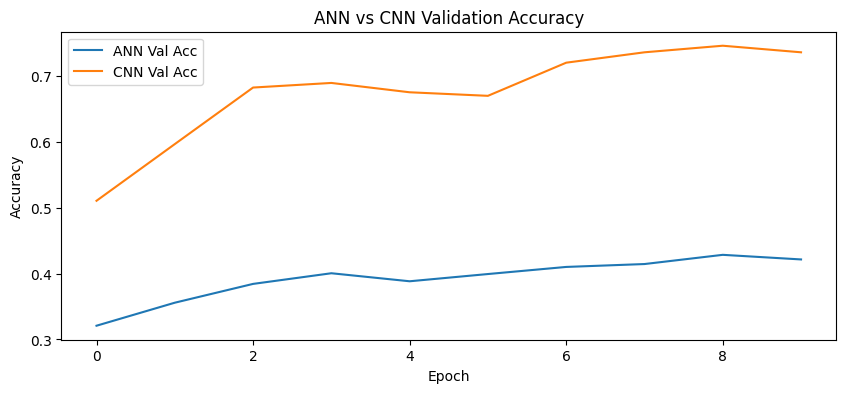

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4236
1,CNN,0.7194


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## My task starts from these cell

## 1. Increase ANN layers and observe performance

In [ ]:
from tensorflow.keras import models, layers

ann_model_improved = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ann = ann_model_improved.fit(
    x_train_flat,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64
)

ann_loss, ann_acc = ann_model_improved.evaluate(x_test_flat, y_test)
print("Improved ANN Accuracy:", ann_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2410 - loss: 2.0448 - val_accuracy: 0.3236 - val_loss: 1.8871
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2995 - loss: 1.9041 - val_accuracy: 0.3342 - val_loss: 1.8458
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3152 - loss: 1.8608 - val_accuracy: 0.3422 - val_loss: 1.8099
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3249 - loss: 1.8297 - val_accuracy: 0.3724 - val_loss: 1.7984
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3321 - loss: 1.8117 - val_accuracy: 0.3672 - val_loss: 1.7510
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3434 - loss: 1.7923 - val_accuracy: 0.3816 - val_loss: 1.7464
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3460 - loss: 1.7797 - val_accuracy: 0.3608 - val_loss: 1.7602
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3490 - loss: 1.7732 - val_accuracy: 0.

## 2.Change CNN filters from 32→64→128

In [ ]:
cnn_model_improved = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

cnn_model_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 3.Increase epochs to 20

In [ ]:
history_cnn = cnn_model_improved.fit(
    x_train_norm,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64
)

cnn_loss, cnn_acc = cnn_model_improved.evaluate(x_test_norm, y_test)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4792 - loss: 1.5363 - val_accuracy: 0.5828 - val_loss: 1.1922
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6216 - loss: 1.0810 - val_accuracy: 0.6436 - val_loss: 1.0050
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6816 - loss: 0.9063 - val_accuracy: 0.6678 - val_loss: 0.9414
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7250 - loss: 0.7917 - val_accuracy: 0.5848 - val_loss: 1.3984
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7550 - loss: 0.6917 - val_accuracy: 0.7058 - val_loss: 0.8901
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7786 - loss: 0.6299 - val_accuracy: 0.6662 - val_loss: 0.9513
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8046 - loss: 0.5574 - val_accuracy: 0.7248 - val_loss: 0.8665
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8243 - loss: 0.4962 - val_accuracy: 

## 4.Add EarlyStopping

In [ ]:
cnn_model_es = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_cnn_es = cnn_model_es.fit(
    x_train_norm,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_loss, cnn_es_acc = cnn_model_es.evaluate(
    x_test_norm,
    y_test
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4786 - loss: 1.5460 - val_accuracy: 0.5452 - val_loss: 1.3245
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6240 - loss: 1.0828 - val_accuracy: 0.6426 - val_loss: 1.0275
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6815 - loss: 0.9096 - val_accuracy: 0.6834 - val_loss: 0.9163
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7200 - loss: 0.8019 - val_accuracy: 0.7078 - val_loss: 0.8508
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7471 - loss: 0.7174 - val_accuracy: 0.7044 - val_loss: 0.8524
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7720 - loss: 0.6401 - val_accuracy: 0.7046 - val_loss: 0.8991
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7969 - loss: 0.5770 - val_accuracy: 0.7166 - val_loss: 0.8461
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8148 - loss: 0.5188 - val_accuracy: 

## 5.Add data augmentation training

In [ ]:


from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


aug_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])


aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_aug = aug_model.fit(
    x_train_norm,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_aug]
)


aug_loss, aug_acc = aug_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print("CNN + Data Augmentation Accuracy:", aug_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.4120 - loss: 1.7254 - val_accuracy: 0.4820 - val_loss: 1.4945
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5196 - loss: 1.3602 - val_accuracy: 0.5296 - val_loss: 1.4100
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5566 - loss: 1.2466 - val_accuracy: 0.5232 - val_loss: 1.3860
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5891 - loss: 1.1686 - val_accuracy: 0.6018 - val_loss: 1.1123
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6108 - loss: 1.1061 - val_accuracy: 0.6434 - val_loss: 1.0239
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6271 - loss: 1.0612 - val_accuracy: 0.6682 - val_loss: 0.9230
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6442 - loss: 1.0188 - val_accuracy: 0.6770 - val_loss: 0.9318
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6592 - loss: 0.9844 - val_acc

## Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Original ANN",
        "Original CNN",
        "Improved ANN",
        "CNN (20 Epochs)",
        "CNN + EarlyStopping",
        "CNN + Data Augmentation"
    ],
    "Epochs": [
        10,
        10,
        20,
        20,
        20,
        20
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_acc,
        cnn_acc,
        cnn_es_acc,
        aug_acc
    ]
})

comparison

,Model,Epochs,Test Accuracy
0,Original ANN,10,0.4236
1,Original CNN,10,0.7194
2,Improved ANN,20,0.3916
3,CNN (20 Epochs),20,0.7241
4,CNN + EarlyStopping,20,0.7099
5,CNN + Data Augmentation,20,0.7004


## Validation Accuracy Comparison Graph

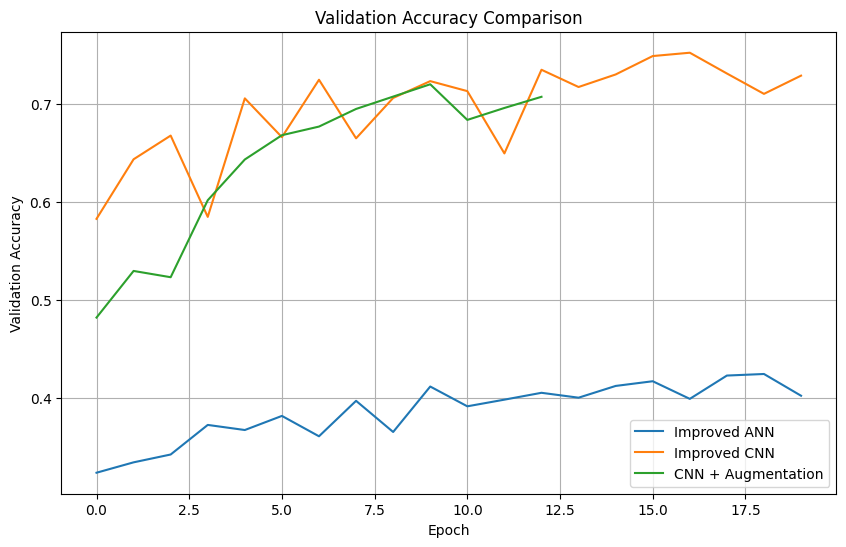

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_ann.history['val_accuracy'],label='Improved ANN')
plt.plot(history_cnn.history['val_accuracy'],label='Improved CNN')
plt.plot(history_aug.history['val_accuracy'],label='CNN + Augmentation')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")

plt.legend()
plt.grid(True)

plt.show()

# Conclusion


1.The Original CNN (71.94%) significantly outperformed the Original ANN (42.36%), demonstrating the advantage of convolutional layers for image classification.

2.Increasing the ANN depth did not improve performance, indicating that simply adding more dense layers cannot compensate for the lack of spatial feature extraction.

3.Increasing CNN training to 20 epochs provided a slight improvement in accuracy (72.41%).

4.Adding EarlyStopping reduced training time and helped prevent overfitting, although the final test accuracy was slightly lower (70.99%).

5.The Data Augmentation model achieved 70.04% accuracy. While it did not surpass the baseline CNN under the current training configuration, augmentation generally improves model robustness and may achieve better performance with additional hyperparameter tuning or longer training.